# Worst Case Headway Time Experiments

In [1]:
from typing import Dict, List, Tuple

import copy
import itertools
import pickle

import plotly
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from policies import *
from routes import *
from wc_analysis import *
from prob_analysis import *

## Plotting Helpers

In [19]:
def plot_headway(results) -> None:
    fig = go.Figure()
    whitespace = 0.2
    width = (1 - whitespace) / len(results.keys())
    for i, name in enumerate(results.keys()):
        offset = -0.5 + 0.5 * whitespace + i * width + 0.5 * width
        for stop_idx in range(len(results[name]['route'])):
            fig.add_trace(go.Bar(
                y=[results[name]['worst_case']['headway'][stop_idx]],
                x=[stop_idx + offset],
                base=[results[name]['best_case']['headway'][stop_idx]],
                width=width,
                opacity=0.5,
                marker={'color': px.colors.qualitative.T10[i]},
                name=name,
                showlegend=True if stop_idx == 0 else False,
            ))
            fig.add_trace(go.Box(
                y=results[name]['simulation']['headway'][stop_idx],
                x=[stop_idx + offset] * len(results[name]['simulation']['headway'][stop_idx]),
                showlegend=False,
                width=width,
                marker={'color':px.colors.qualitative.T10[i]},
            ))

    fig.update_yaxes(
        title_text='Headway Time (min.)',
    )

    fig.update_layout(
        xaxis=dict(
            tickmode='array',
            tickvals=[j for j in range(len(results[name]['route']))],
            title='Stop #',
        ), 
        legend=dict(
            xanchor='right',
            x=1.15
        ),
        #title=dict(text='Per Stop Simulated Headway vs. Theoretical Bound', xanchor="center"),
    )

    fig.show()

In [20]:
def plot_travel(results):
    fig = make_subplots(
        rows=2,
        cols=len(results.keys()),
        column_titles=list(results.keys()),
        row_titles=['Upper Bound', 'Actual'],
        x_title="To Stop #",
        y_title="Worst Case<br>Trave Time From Stop #",
    )

    # Normalize Color Scales
    absolute_max = 0
    absolute_min = 1e6
    for name in results.keys():
        for i in results[name]['worst_case']['travel']:
            absolute_max = max(absolute_max, max(i))
            absolute_min = min(absolute_min, min(i))
        for i in results[name]['simulation']['travel']:
            for j in i:
                absolute_max = max(absolute_max, max(j))
                absolute_min = min(absolute_min, min(j))
    
    # Plot The Thing
    for i, name in enumerate(results.keys()):
        fig.add_trace(
            go.Heatmap(
                z=results[name]['worst_case']['travel'],
                text=results[name]['worst_case']['travel'],
                texttemplate="%{text:.0f}",
                showscale=False,
                zmax=absolute_max,
                zmin=absolute_min,
                #textfont={"size":10}
            ),
            row=1,
            col=i + 1,
        )
    for i, name in enumerate(results.keys()):
        z = [[max(k) for k in j] for j in results[name]['simulation']['travel']]
        fig.add_trace(
            go.Heatmap(
                z=z,
                text=z,
                texttemplate="%{text:.0f}",
                showscale=False,
                zmax=absolute_max,
                zmin=absolute_min,
                #textfont={"size":10}
            ),
            row=2,
            col=i + 1,
        )

    fig.show()

In [21]:
def run_experiment(exp_id: str, routes: Dict, start_times: List[List[float]], t_max: int = 60 * 24 * 7) -> None:
    results = {}
    for name, route in routes.items():
        print(f'Working on {name}...')
        wc_headway, bc_headway = wcht(route_factory(route), start_times, t_max)
        wc_travel = []
        for i in range(len(route)):
            wc_travel.append([])
            for j in range(len(route)):
                wc_travel[i].append(wctt(route_factory(route), start_times, wc_headway, i, j))
        prob_results = simulate(route_factory(route), start_times, t_max, seed=0)
        results[name] = {
            'worst_case': {'headway': wc_headway, 'travel': wc_travel},
            'best_case': {'headway': bc_headway},
            'simulation': prob_results,
            'route': route
        }

    with open(f'results-{exp_id}.pkl', 'wb') as res_f_ptr:
        res_f_ptr.write(pickle.dumps(results))

    plot_headway(results)
    plot_travel(results)


## Fig 1: Tightness of bounds with one control point
Make sure this works before proceeding.


Working on Uncontrolled...
Working on Schedule Policy...
Working on Headway Policy...


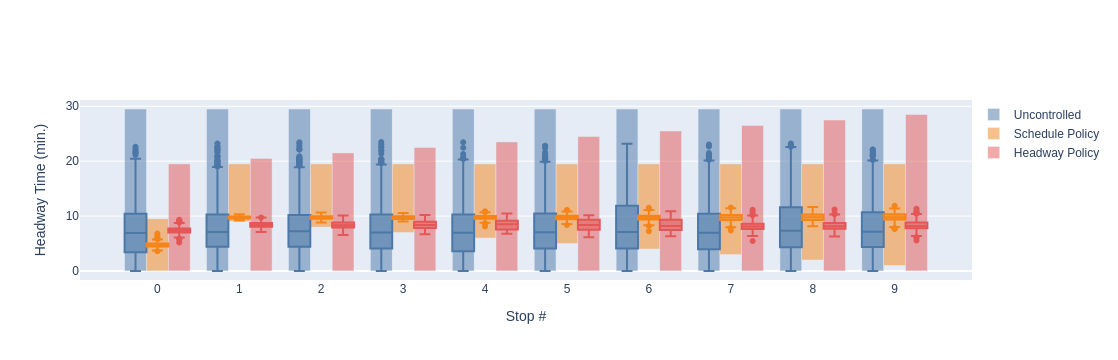

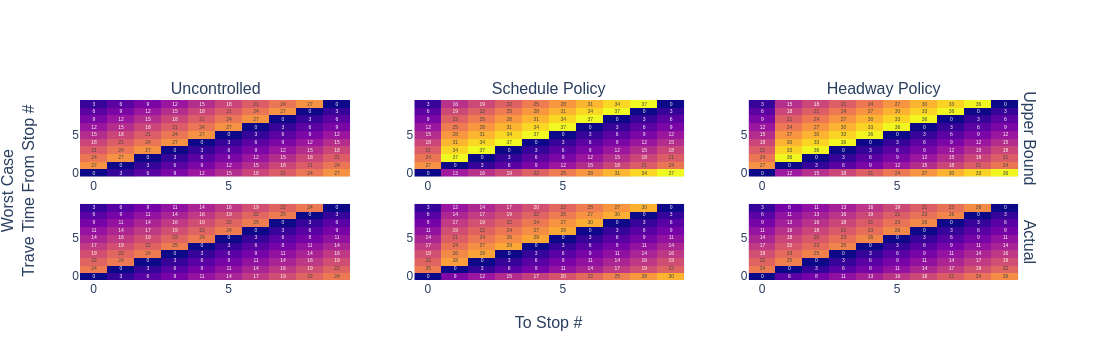

In [22]:
# Base route - no control
BASE_ROUTE = [
    {
        'tau': (2, 2.5),
        'delta': (0.0, 0.5),
        'policy': BolehPolicy,
        'policy_args': {},
    } for _ in range(10)
]

# Scheduled terminal departure
SCHED_ROUTE = copy.deepcopy(BASE_ROUTE)
SCHED_ROUTE[0]['policy'] = LeakyBucketPolicy
SCHED_ROUTE[0]['policy_args'] = {'time_delta': 10, 'offset': 0}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': float('inf')}

# Headway Driven Route tries to maintain constant headway regardless of delay
HEADWAY_ROUTE = copy.deepcopy(BASE_ROUTE)
HEADWAY_ROUTE[0]['policy'] = HeadwayDrivenPolicy
HEADWAY_ROUTE[0]['policy_args'] = {'target_headway': 10}

routes = {
    'Uncontrolled': BASE_ROUTE,
    'Schedule Policy': SCHED_ROUTE,
    'Headway Policy': RATIO_ROUTE,
}

run_experiment(
    exp_id='exp-base',
    routes=routes,
    start_times=[0, 10, 20],
    t_max=60 * 24 * 7,
)

## Fig. 1: All Points Controlled
We now consider the effects of different policies when applied to every stop along a route.

Setting:
* 10 stops, average completion time uncontrolled: 60 minutes
* 6 vehicles

TODO:
* Outlier headway time on Headway Policy when buses released simultaneously

Working on Uncontrolled...
Working on Schedule Driven...
Working on H/T Ratio Driven...


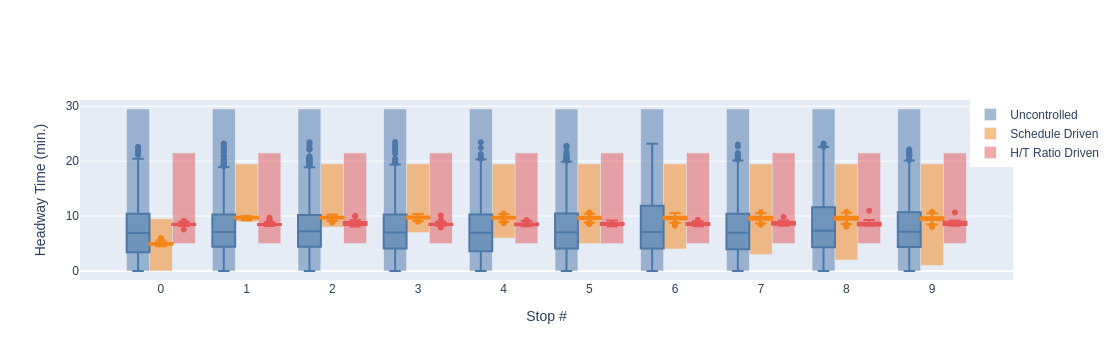

In [6]:
# Base route - no control
N_STOPS = 10
BASE_ROUTE = [
    {
        'tau': (2, 2.5),
        'delta': (0, 0.5),
        'policy': BolehPolicy,
        'policy_args': {},
    } for _ in range(N_STOPS)
]

# Scheduled terminal departure
SCHED_ROUTE = copy.deepcopy(BASE_ROUTE)
for i in range(N_STOPS):
    SCHED_ROUTE[i]['policy'] = LeakyBucketPolicy
    SCHED_ROUTE[i]['policy_args'] = {'time_delta': 10, 'offset':  2.5 * i}


# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE = copy.deepcopy(BASE_ROUTE)
for i in range(N_STOPS):
    RATIO_ROUTE[i]['policy'] = RatioDrivenPolicy
    RATIO_ROUTE[i]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': float('inf')}


routes = {
    'Uncontrolled': BASE_ROUTE,
    'Schedule Driven': SCHED_ROUTE,
    'H/T Ratio Driven': RATIO_ROUTE,
}

run_experiment(
    exp_id='fig1-policy-comparison',
    routes=routes,
    start_times=[0, 10, 20],
    t_max=60 * 24 * 7,
)

## Fig. 2: Terminal and Midpoint Holding Only
We now consider the effect of applying a policy only at the terminal and at route midpoint.  The setting is the same as the previous figure.

TODO:
* Travel time calculation is incorrect for headway 

In [7]:
# Base route - no control
N_STOPS = 10
BASE_ROUTE = [
    {
        'tau': (1, 2),
        'delta': (0.5, 1),
        'policy': BolehPolicy,
        'policy_args': {},
    } for _ in range(N_STOPS)
]

# Scheduled terminal departure
SCHED_ROUTE = copy.deepcopy(BASE_ROUTE)
SCHED_ROUTE[0]['policy'] = LeakyBucketPolicy
SCHED_ROUTE[0]['policy_args'] = {'time_delta': 10, 'offset': 0}
SCHED_ROUTE[5]['policy'] = LeakyBucketPolicy
SCHED_ROUTE[5]['policy_args'] = {'time_delta': 10, 'offset': 2.25 * 5}


# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 10}
RATIO_ROUTE[5]['policy'] = RatioDrivenPolicy
RATIO_ROUTE[5]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 10}


# Headway Driven Route tries to maintain constant headway regardless of delay
HEADWAY_ROUTE = copy.deepcopy(BASE_ROUTE)
HEADWAY_ROUTE[0]['policy'] = HeadwayDrivenPolicy
HEADWAY_ROUTE[0]['policy_args'] = {'target_headway': 10}
HEADWAY_ROUTE[5]['policy'] = HeadwayDrivenPolicy
HEADWAY_ROUTE[5]['policy_args'] = {'target_headway': 10}

routes = {
    'Uncontrolled': BASE_ROUTE,
    'Schedule Driven': SCHED_ROUTE,
    'Headway Driven': HEADWAY_ROUTE,
    'H/T Ratio Driven': RATIO_ROUTE,
}

run_experiment(
    exp_id='fig2-midpoint-holding',
    routes=routes,
    start_times=[0, 10, 20, 30],

    t_max=60 * 24 * 7,
)

Working on Uncontrolled...
Working on Schedule Driven...
Working on Headway Driven...


UnboundLocalError: cannot access local variable 'i' where it is not associated with a value

## Fig. 3: Number of Vehicles
Show the impact number of vehicles has on the same scheduling policy


In [ ]:
# Base route - no control
BASE_ROUTE = [
    {
        'tau': (9, 10),
        'delta': (2, 3),
        'policy': BolehPolicy,
        'policy_args': {},
    } for _ in range(9)
]

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE0 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE0[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE0[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.99, 'max_holding': 100}
RATIO_ROUTE0[4]['policy'] = RatioDrivenPolicy
RATIO_ROUTE0[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.99, 'max_holding': 100}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE1 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE1[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE1[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.75, 'max_holding': 100}
RATIO_ROUTE1[4]['policy'] = RatioDrivenPolicy
RATIO_ROUTE1[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.75, 'max_holding': 100}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE2 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE2[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE2[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.5, 'max_holding': 100}
RATIO_ROUTE2[4]['policy'] = RatioDrivenPolicy
RATIO_ROUTE2[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.5, 'max_holding': 100}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE3 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE3[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE3[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.25, 'max_holding': 100}
RATIO_ROUTE3[4]['policy'] = RatioDrivenPolicy
RATIO_ROUTE3[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.25, 'max_holding': 100}

routes = {
    'H/T Activated@1.00': RATIO_ROUTE0,
    'H/T Activated@0.75': RATIO_ROUTE1,
    'H/T Activated@0.50': RATIO_ROUTE2,
    'H/T Activated@0.25': RATIO_ROUTE3,
}

run_experiment(
    exp_id='midpoint_holding',
    routes=routes,
    start_times=[0, 0, 0, 0, 0, 0, 0, 0, 0],
    t_max=60 * 24 * 7,
)

## Midpoint Control (Changing Headway Target)

In [ ]:
# Base route - no control
BASE_ROUTE = [
    {
        'tau': (1, 2),
        'delta': (0.5, 1),
        'policy': BolehPolicy,
        'policy_args': {},
    } for _ in range(10)
]

# Scheduled terminal departure
SCHED_ROUTE = copy.deepcopy(BASE_ROUTE)
SCHED_ROUTE[9]['policy'] = LeakyBucketPolicy
SCHED_ROUTE[9]['policy_args'] = {'time_delta': 10, 'offset': 0}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE[9]['policy'] = RatioDrivenPolicy
RATIO_ROUTE[9]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.99, 'max_holding': 20}

# Ratio Driven Route has one stop driven by ratio policy
HEADWAY_ROUTE = copy.deepcopy(BASE_ROUTE)
HEADWAY_ROUTE[9]['policy'] = HeadwayDrivenPolicy
HEADWAY_ROUTE[9]['policy_args'] = {'target_headway': 10}

routes = {
    'Uncontrolled': BASE_ROUTE,
    'Schedule': SCHED_ROUTE,
    'Dynamic': RATIO_ROUTE,
}

run_experiment(
    exp_id='midpoint_holding',
    routes=routes,
    start_times=[0, 10, 20, 30],
    t_max=60 * 24 * 7,
)


What we want to show:
1. Schedule driven can drive headway time down only if travel time spread is small
2. Headway driven performs, but suffers in travel time
3. Ratio driven gives best of both worlds and puts a bound
4. What happens when we play with holding parameters?
5. Is it better to hold

Assumptions
1. route operator has control only of policy and stops to implement it

Fig. 1:
1 Control Point (Bars and Box)

Fig. 2:
N Control Points -> WCHT (Line?)

Fig. 3:
Control Point Location (Bars and Box) -> Dyanamic Holding

Fig. 4:
Control Point Parameters -> (Bars and Box) -> Dynamic Holding

Fig. 5:
Show affect of # vehicles on hold times


Last figure:
Show percentiles on real route